In [28]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

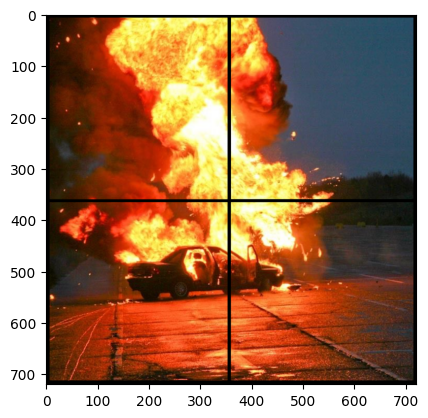

In [29]:
meledak = cv2.imread('Meledak.png')
meledak = cv2.cvtColor(meledak, cv2.COLOR_BGR2RGB)
plt.imshow(meledak)
plt.axis('on')
plt.show()

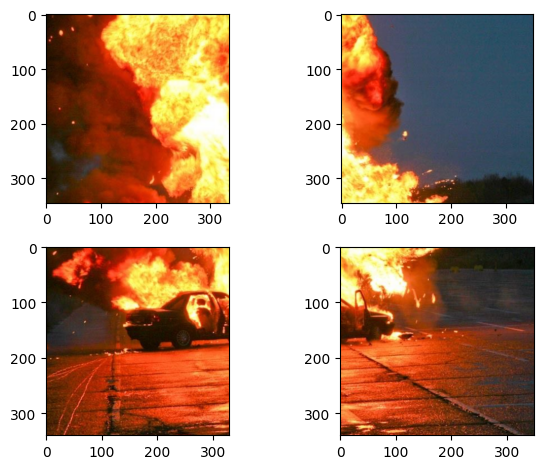

In [30]:
meledak1 = meledak[15:360, 15:350]
meledak2 = meledak[15:360, 365:715]
meledak3 = meledak[370:710, 15:345]
meledak4 = meledak[370:710, 365:715]

plt.subplot(2, 2, 1)
plt.imshow(meledak1)
plt.axis('on')

plt.subplot(2, 2, 2)
plt.imshow(meledak2)
plt.axis('on')

plt.subplot(2, 2, 3)
plt.imshow(meledak3)
plt.axis('on')

plt.subplot(2, 2, 4)
plt.imshow(meledak4)
plt.axis('on')

plt.tight_layout()
plt.show()

In [31]:
def merge_image(citra1, citra2, orientation='H'):
    if orientation == 'H':
        tinggi = max(citra1.shape[0], citra2.shape[0])
        lebar_total = citra1.shape[1] + citra2.shape[1]
        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype)
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2
    else:
        tinggi_total = citra1.shape[0] + citra2.shape[0]
        lebar = max(citra1.shape[1], citra2.shape[1])
        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype)
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2
    return gabungan

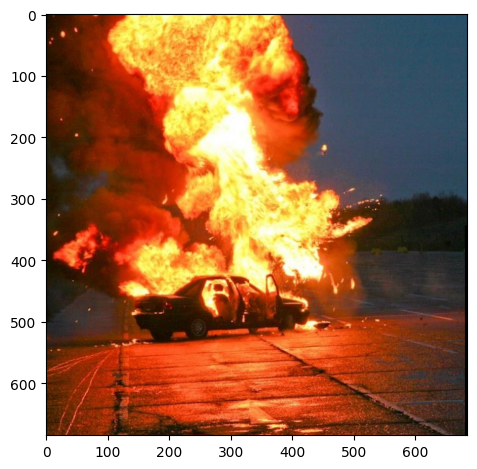

In [32]:
gabung1 = merge_image(meledak1, meledak2, orientation='H')
gabung2 = merge_image(meledak3, meledak4, orientation='H')
gabung_final = merge_image(gabung1, gabung2, orientation='V')

plt.imshow(gabung_final)
plt.tight_layout()
plt.show()

In [33]:
def ekualisasi(image):
    hist = np.zeros(256, dtype=int)
    height, width = image.shape
    for i in range(height):
        for j in range(width):
            val = image[i, j]
            hist[val] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    hasil = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        nilai = int(np.round((cdf[i] * 255) / (height * width)))
        if nilai > 255:
            nilai = 255
        hasil[i] = nilai
    return hasil

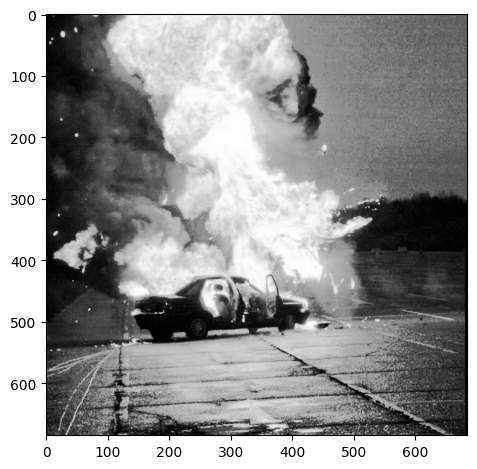

In [34]:
# Konversi gabung_final ke grayscale menggunakan cv2 (uint8 0-255)
gabung_final_gray = cv2.cvtColor(gabung_final, cv2.COLOR_RGB2GRAY)

eq_map = ekualisasi(gabung_final_gray)
img_eq = eq_map[gabung_final_gray]
hasil_ekualisasi = img_eq

plt.imshow(img_eq, cmap='gray')
plt.tight_layout()
plt.show()

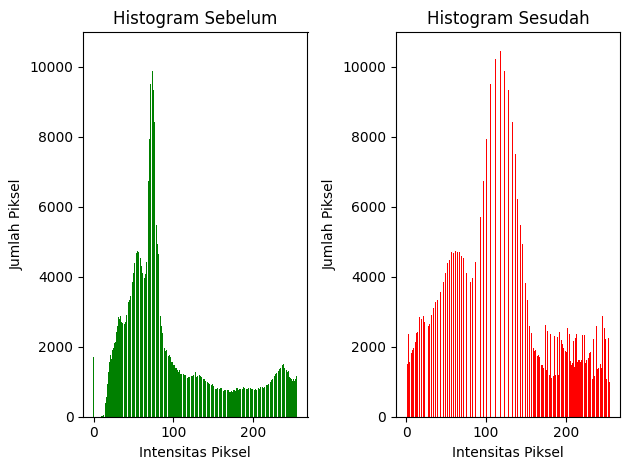

In [35]:
def buat_hist(citra, intensitas=256):
    histogram = np.zeros(intensitas, dtype=int)
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    for i in range(tinggi):
        for j in range(lebar):
            val = int(citra[i][j])
            if val < intensitas:
                histogram[val] += 1
    return histogram

def plot_histogram(citra, ImgColor, title, intensitas=256):
    histogram = buat_hist(citra, intensitas)
    plt.bar(range(intensitas), histogram, color=ImgColor, width=0.8)
    plt.title(title)
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel')


plt.subplot(1, 2, 1)
plot_histogram(gabung_final_gray, 'green', 'Histogram Sebelum')

plt.subplot(1, 2, 2)
plot_histogram(hasil_ekualisasi, 'red', 'Histogram Sesudah')

plt.tight_layout()
plt.show()

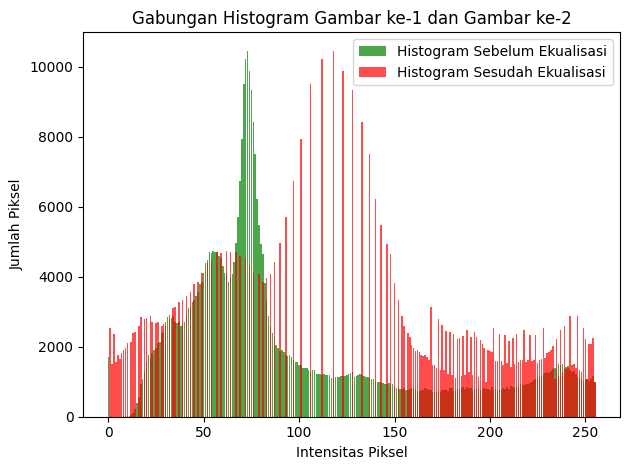

In [36]:
hist_before = buat_hist(gabung_final_gray)
hist_after  = buat_hist(hasil_ekualisasi)

plt.bar(range(256), hist_before, color='green', alpha=0.7, label='Histogram Sebelum Ekualisasi')
plt.bar(range(256), hist_after,  color='red',   alpha=0.7, label='Histogram Sesudah Ekualisasi')
plt.title('Gabungan Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.legend()
plt.tight_layout()
plt.show()

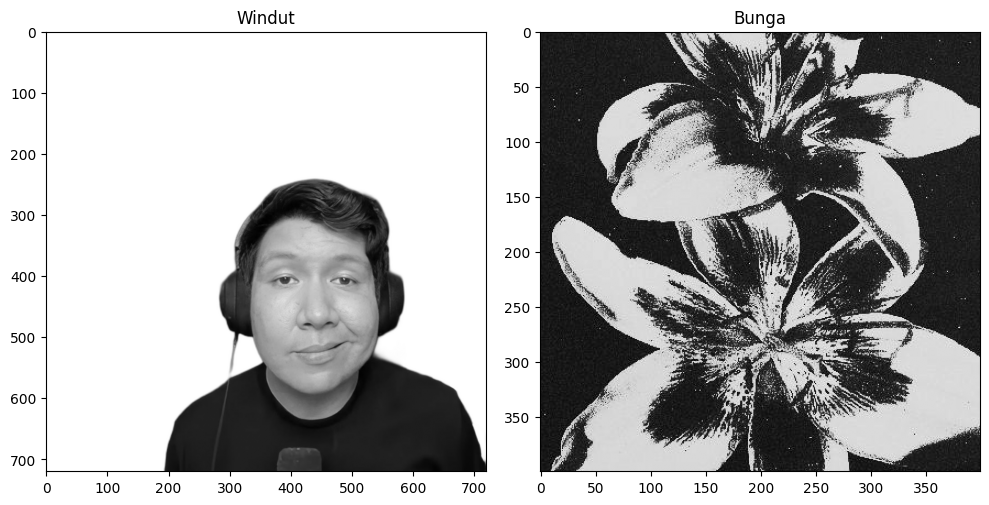

In [37]:
windah = cv2.imread('Windut.png')
Bunga  = cv2.imread('Bunga.png')

windah_abu = cv2.cvtColor(windah, cv2.COLOR_BGR2GRAY)
bunga_abu  = cv2.cvtColor(Bunga,  cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(windah_abu, cmap='gray')
plt.title('Windut')

plt.subplot(1, 2, 2)
plt.imshow(bunga_abu, cmap='gray')
plt.title('Bunga')

plt.tight_layout()
plt.show()

In [38]:
def hitung_hist_dan_cdf(citra):
    tinggi, lebar = citra.shape
    hist = np.zeros(256, dtype=int)
    for i in range(tinggi):
        for j in range(lebar):
            hist[citra[i, j]] += 1
    cdf = np.zeros(256, dtype=float)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
    max_cdf = cdf[255]
    for i in range(256):
        cdf[i] = cdf[i] / max_cdf
    return cdf

def spesifikasi_histogram(citra_asal, citra_target):
    cdf_asal   = hitung_hist_dan_cdf(citra_asal)
    cdf_target = hitung_hist_dan_cdf(citra_target)
    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        selisih_terkecil = 2.0
        index_terbaik = 0
        for j in range(256):
            selisih = abs(cdf_target[j] - cdf_asal[i])
            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                index_terbaik = j
        map_hist[i] = index_terbaik
    tinggi, lebar = citra_asal.shape
    hasil = np.zeros((tinggi, lebar), dtype=np.uint8)
    for i in range(tinggi):
        for j in range(lebar):
            hasil[i, j] = map_hist[citra_asal[i, j]]
    return hasil

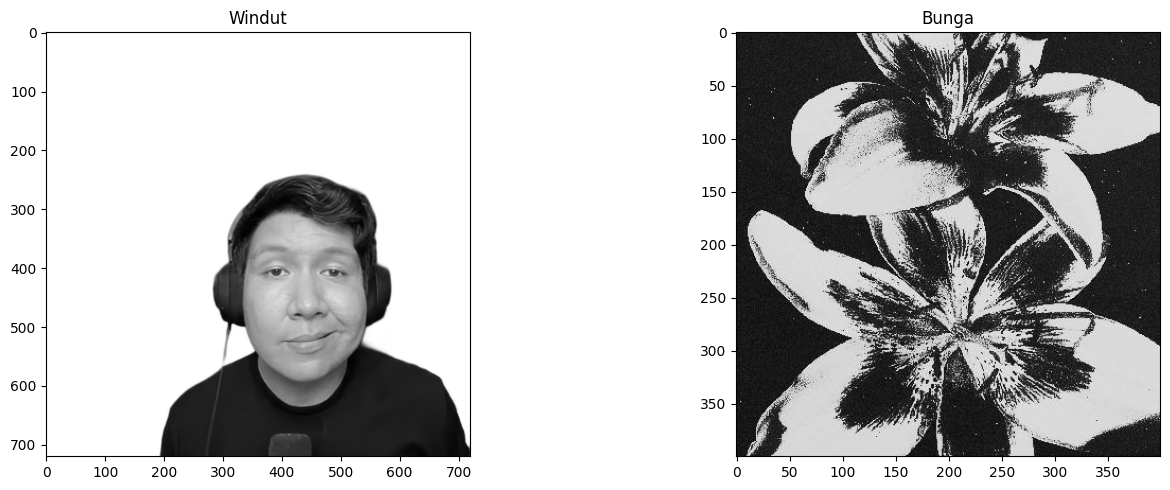

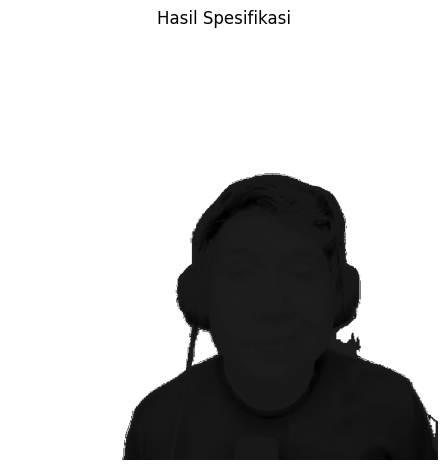

In [39]:
spesifikasi = spesifikasi_histogram(windah_abu, bunga_abu)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(windah_abu, cmap='gray')
plt.title('Windut')

plt.subplot(1, 2, 2)
plt.imshow(bunga_abu, cmap='gray')
plt.title('Bunga')

plt.tight_layout()
plt.show()

plt.imshow(spesifikasi, cmap='gray')
plt.title('Hasil Spesifikasi')
plt.axis('off')
plt.tight_layout()
plt.show()

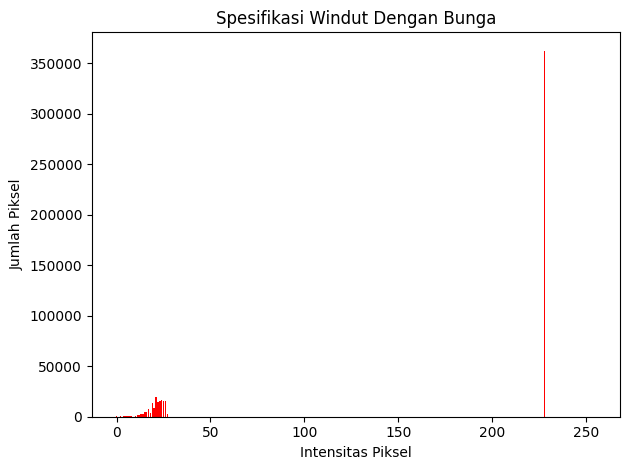

In [40]:
plot_histogram(spesifikasi, 'red', 'Spesifikasi Windut Dengan Bunga')
plt.tight_layout()
plt.show()

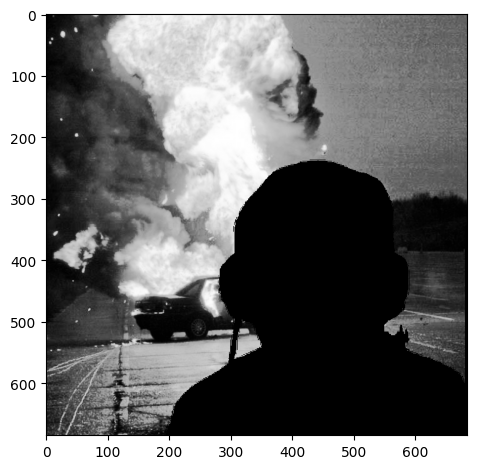

In [41]:
def crop(img1, img2):
    if img1.shape[0] < img2.shape[0]:
        target_tinggi = img1.shape[0]
    else:
        target_tinggi = img2.shape[0]
    if img1.shape[1] < img2.shape[1]:
        target_lebar = img1.shape[1]
    else:
        target_lebar = img2.shape[1]
    hasil1 = img1[:target_tinggi, :target_lebar]
    hasil2 = img2[:target_tinggi, :target_lebar]
    return hasil1, hasil2

windut_crop, meledak_crop = crop(spesifikasi, img_eq)

hasil_gabung = np.zeros((windut_crop.shape[0], windut_crop.shape[1]), dtype=np.uint8)

for i in range(windut_crop.shape[0]):
    for j in range(windut_crop.shape[1]):
        if windut_crop[i, j] > 200:
            hasil_gabung[i, j] = meledak_crop[i, j]
        else:
            hasil_gabung[i, j] = 0

plt.imshow(hasil_gabung, cmap='gray')
plt.tight_layout()
plt.show()

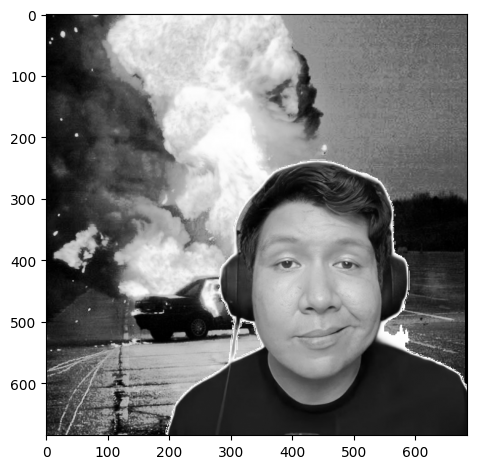

In [42]:
h = min(spesifikasi.shape[0], img_eq.shape[0])
w = min(spesifikasi.shape[1], img_eq.shape[1])

windut_spec_crop = spesifikasi[:h, :w]
windut_asli_crop = windah_abu[:h, :w]
meledak_crop_fix = img_eq[:h, :w]

hasil_gabung2 = np.zeros((h, w), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        if windut_spec_crop[i, j] < 50:
            hasil_gabung2[i, j] = windut_asli_crop[i, j]
        else:
            hasil_gabung2[i, j] = meledak_crop_fix[i, j]

plt.imshow(hasil_gabung2, cmap='gray')
plt.tight_layout()
plt.show()

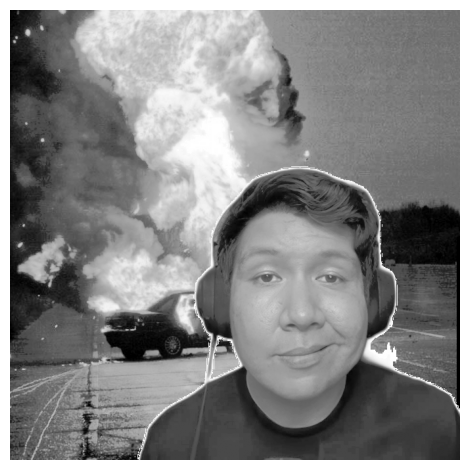

In [43]:
Langit = cv2.imread('Langit.png')
Langit = cv2.cvtColor(Langit, cv2.COLOR_BGR2GRAY)

finalwindut = spesifikasi_histogram(hasil_gabung2, Langit)


plt.imshow(finalwindut, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

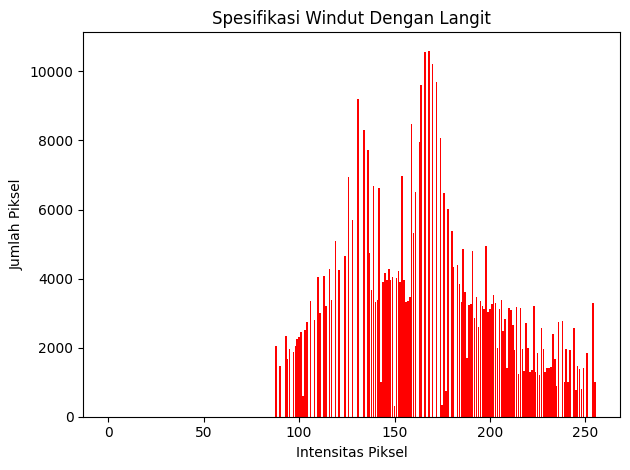

In [44]:
plot_histogram(finalwindut, 'red', 'Spesifikasi Windut Dengan Langit')
plt.tight_layout()
plt.show()

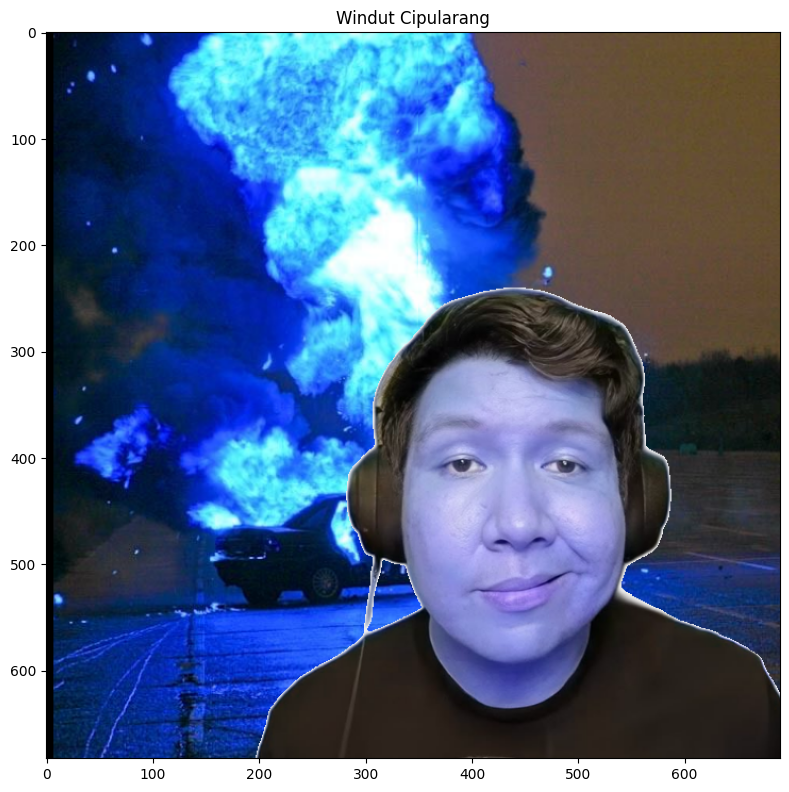

In [64]:
Default_Meledak = cv2.imread('Meledak.png')  # BGR, jangan dikonversi

Default_Meledak00 = Default_Meledak[7:360, :350]
Default_Meledak01 = Default_Meledak[7:360, 360:700]
Default_Meledak10 = Default_Meledak[370:700, :350]
Default_Meledak11 = Default_Meledak[370:700, 360:700]

MergedHor1_Default  = merge_image(Default_Meledak00, Default_Meledak01, orientation='H')
MergedHor2_Default  = merge_image(Default_Meledak10, Default_Meledak11, orientation='H')
FinalMerged_Default = merge_image(MergedHor1_Default, MergedHor2_Default, orientation='V')
Default_Windut = cv2.imread('Windut.png')  # BGR, jangan dikonversi

Default_Windut_crop, FinalMerged_crop = crop(Default_Windut, FinalMerged_Default)

merged_default = np.zeros((Default_Windut_crop.shape[0], Default_Windut_crop.shape[1], 3), dtype=np.uint8)

for i in range(Default_Windut_crop.shape[0]):
    for j in range(Default_Windut_crop.shape[1]):
        if Default_Windut_crop[i, j].sum() > 240 * 3:
            merged_default[i, j] = FinalMerged_crop[i, j]
        else:
            merged_default[i, j] = Default_Windut_crop[i, j]

# TANPA cvtColor - biarkan BGR agar warna biru muncul seperti jurnal
plt.figure(figsize=(8, 8))
plt.imshow(merged_default)
plt.title('Windut Cipularang')
plt.tight_layout()
plt.show()